# Comprehensive Dataset Preprocessing: The Titanic Dataset


## Dataset Name & Origin

The Titanic dataset is a classic real-world dataset from the Kaggle Titanic competition, originally sourced from historical records of the RMS Titanic disaster in 1912. It contains information about 891 passengers.

## Real-World Interpretation of the Problem

This dataset represents passenger details from the Titanic voyage, including demographics, ticket information, and survival status. The real-world problem is predicting survival based on features like class, age, gender, etc. – similar to risk assessment in emergencies or insurance.

## Why This Dataset is Suitable for Preprocessing Learning

Titanic is ideal because it has missing values (e.g., Age ~20% missing, Cabin ~77%), mixed types (numerical like Fare, categorical like Sex), outliers (high Fares), skewed distributions (Fare is right-skewed), potential leakage risks (e.g., if deriving features from Name after split), and realistic imperfections (e.g., invalid or duplicate tickets possible, but we'll check).


## Learning Objectives

By the end of this notebook, you will be able to:

- Load and initially inspect a raw dataset to identify quality issues.
- Frame the ML problem by analyzing the target variable and potential pitfalls like imbalance or leakage.
- Handle missing values in multiple columns by evaluating and choosing strategies based on data semantics and impact.
- Correct data types and distinguish between technical and semantic meanings of features.
- Detect and resolve duplicates and invalid data using domain knowledge.
- Process categorical variables by selecting appropriate encoding methods and justifying choices.
- Analyze and transform numerical features, including outlier handling and scaling, with visual support.
- Perform train/test split correctly to prevent data leakage.
- Build and apply a preprocessing pipeline using scikit-learn tools.
- Verify the final ML-ready dataset through sanity checks.
- Avoid common preprocessing mistakes and reflect on subjective decisions.


## Dataset Loading & First Contact

We start by loading the dataset and taking a slow, deliberate look. Rushing here leads to missed issues later. Always check shape, dtypes, head/tail, and describe early.


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer


In [3]:

# Load the Titanic dataset using Seaborn for convenience
titanic_df = sns.load_dataset('titanic')

# Display first 5 rows
print('First 5 rows:')
display(titanic_df.head())

# Shape
print('\n')
print("="*30)
print('Shape:', titanic_df.shape)
print("="*30)
print('\n')
# Columns and dtypes
print('\n')
print("="*30)
print('Data types:')
display(titanic_df.dtypes)
print("="*30)
print('\n')

# Initial summary
print('Summary statistics:')
display(titanic_df.describe(include='all'))

# Initial warnings: Already see NaN in age, embarked, deck, embark_town. Deck has many missings. Pclass is int but likely categorical. Survived is int but binary category. Fare skewed (max 512 vs mean 32).

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True




Shape: (891, 15)




Data types:


survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object



Summary statistics:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Target Variable & Problem Framing

The target is 'survived' (0=did not survive, 1=survived). This is a binary classification problem.

Check imbalance:

- Value counts: Let's see the distribution.

Potential pitfalls:

- Imbalance: More non-survivors, so stratify splits.
- Leakage: Features like 'alive' are direct leaks (remove). 'deck' might correlate with class, but missings could bias.


survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


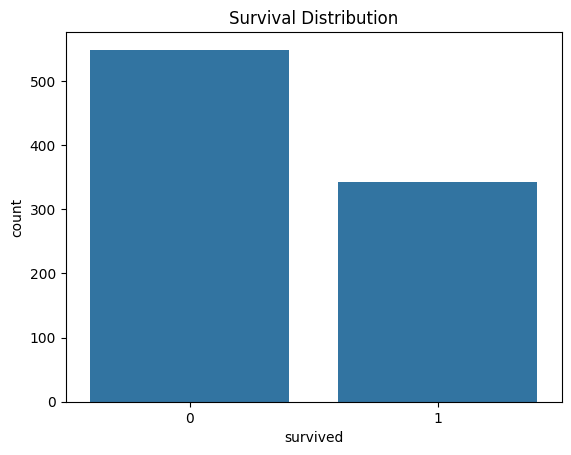

Remaining columns: Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'deck'],
      dtype='object')


In [4]:
# Target distribution
print(titanic_df['survived'].value_counts(normalize=True))

# Plot
sns.countplot(x='survived', data=titanic_df)
plt.title('Survival Distribution')
plt.show()

# Drop obvious leaks like 'alive', 'embark_town' (duplicate of embarked), 'class' (duplicate of pclass), 'who' (derived from sex/age), 'adult_male' (derived), 'alone' (derived from sibsp/parch)
titanic_df = titanic_df.drop(columns=['alive', 'embark_town', 'class', 'who', 'adult_male', 'alone'])
print('Remaining columns:', titanic_df.columns)

## Missing Values — Deep & Exhaustive

We handle missings column by column. Always calculate counts/percentages first.

Columns with missings: age (177/891 ~19.9%), deck (688/891 ~77.2%), embarked (2/891 ~0.2%).


In [5]:
# Missing counts and percentages
missing = titanic_df.isnull().sum()
missing_pct = (missing / len(titanic_df)) * 100
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct}).sort_values('count', ascending=False)
display(missing_df[missing_df['count'] > 0])

,count,pct
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467


### Deck (Categorical, 77% missing)

Why missing? Deck info likely not recorded for lower-class passengers or lost in records.

Options:

- Drop rows: Loses 77% data – too much.
- Drop column: Viable since high missing, but deck correlates with class/survival (upper decks better).
- Mode imputation: Most common 'C', but biased.
- Group-wise: Impute by pclass (e.g., mode per class).
- Model-based: Use KNN imputer (but conceptual here).
- Leave missing: Treat 'missing' as category.

When to use drop column: High missing (>50%), low info.
When not: If feature important.

Choice: Drop column – too many missings, redundant with pclass. Justify: Avoid imputation bias in small dataset.


In [7]:
# # Example: Mode imputation (not chosen)
# print('Mode:', titanic_df['deck'].mode()[0])
# # titanic_df['deck'] = titanic_df['deck'].fillna(titanic_df['deck'].mode()[0]) # Not doing

# Group-wise example
group_mode = titanic_df.groupby('pclass')['deck'].apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
print('Mode per pclass:', group_mode)

# # Chosen: Drop
# titanic_df = titanic_df.drop(columns=['deck'])

Mode per pclass: pclass
1    C
2    F
3    F
Name: deck, dtype: object


### Age (Numerical, 20% missing)

Why missing? Perhaps not recorded for children or lower class.

Options:

- Drop rows: Loses 20% – acceptable but check bias (missings in lower class?).
- Drop column: Age important for survival (children/women first).
- Mean/median: Mean ~29.7, median 28 – use median for skew.
- Group-wise: Median by pclass/sex (better, captures differences).
- Model-based: Regress age from other features.
- Leave missing: Not for numerical ML.

When mean: Symmetric dist.
When median: Skewed.
When not impute: If missing not random (MNAR).

Choice: Group-wise median – preserves relationships.


After drop rows: (714, 9)
Mean age: 29.69911764705882
Median age: 28.0
Missings after: 0


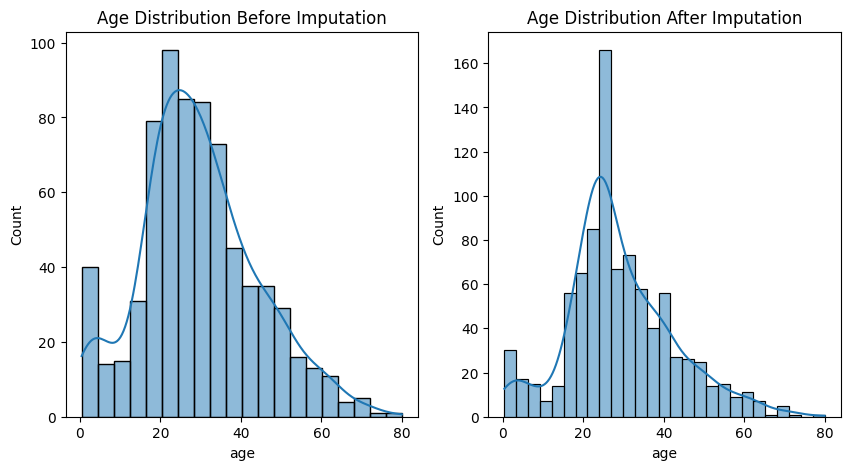

In [8]:
# Before imputation visual
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(titanic_df['age'], kde=True)
plt.title('Age Distribution Before Imputation')

# Example: Drop rows
drop_rows_ex = titanic_df.dropna(subset=['age'])
print('After drop rows:', drop_rows_ex.shape) # Example only

# Mean imputation
mean_age = titanic_df['age'].mean()
print('Mean age:', mean_age)

# Median
median_age = titanic_df['age'].median()
print('Median age:', median_age)

# Group-wise (chosen)
titanic_df['age'] = titanic_df.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))
print('Missings after:', titanic_df['age'].isnull().sum())

# After imputation visual
plt.subplot(1, 2, 2)
sns.histplot(titanic_df['age'], kde=True)
plt.title('Age Distribution After Imputation')
plt.show()

# Interpretation: Notice the distribution might show spikes at medians for groups, but overall shape preserved.

### Embarked (Categorical, 0.2% missing)

Why missing? Likely clerical error.

Options:

- Drop rows: Only 2, minimal loss.
- Drop column: Not, as port might matter.
- Mode: 'S' most common.
- Group-wise: Rare.
- Leave missing: As category 'unknown'.

When drop rows: Low missing.
When mode: For categories.

Choice: Mode – simple, low impact.


In [ ]:
# Before visual (counts)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='embarked', data=titanic_df)
plt.title('Embarked Before Imputation')

# Mode imputation (chosen)
titanic_df['embarked'] = titanic_df['embarked'].fillna(titanic_df['embarked'].mode()[0])
print('Missings after:', titanic_df['embarked'].isnull().sum())

# After visual
plt.subplot(1, 2, 2)
sns.countplot(x='embarked', data=titanic_df)
plt.title('Embarked After Imputation')
plt.show()

# Interpretation: Minimal change since only 2 missings, likely added to 'S'.

## Data Types & Semantic Meaning

Technical dtypes may mismatch semantics. E.g., pclass int but ordinal category.


In [9]:
# Current dtypes
print(titanic_df.dtypes)

# Convert:
# pclass: int -> category (ordinal)
titanic_df['pclass'] = titanic_df['pclass'].astype('category')

# survived: int -> category (binary)
titanic_df['survived'] = titanic_df['survived'].astype('category')

# sex, embarked: object -> category
titanic_df['sex'] = titanic_df['sex'].astype('category')
titanic_df['embarked'] = titanic_df['embarked'].astype('category')

# sibsp, parch: int, but could be categorical if low cardinality
print('sibsp unique:', titanic_df['sibsp'].unique())
# Keep int for now, as numerical in models.

# No dates here.
print('Updated dtypes:')
print(titanic_df.dtypes)

survived       int64
pclass         int64
sex           object
age          float64
sibsp          int64
parch          int64
fare         float64
embarked      object
deck        category
dtype: object
sibsp unique: [1 0 3 4 2 5 8]
Updated dtypes:
survived    category
pclass      category
sex         category
age          float64
sibsp          int64
parch          int64
fare         float64
embarked    category
deck        category
dtype: object


## Duplicate & Invalid Data

Check duplicates: None expected, but always verify.
Invalid: Age <0? Fare <=0? Domain: Age 0-80 ok, but check negatives.


In [ ]:
# Duplicates
dups = titanic_df.duplicated()
print('Duplicates Before:', dups.sum())
titanic_df = titanic_df.drop_duplicates()
dups = titanic_df.duplicated()
print('Duplicates After:', dups.sum())

# Invalid: Negative ages?
print('Negative age:', (titanic_df['age'] < 0).sum())
# Zero fare? Some are 0 (crew?), but ok if domain allows.
print('Zero fare:', (titanic_df['fare'] == 0).sum())
# Decide: Keep 0 fares, as possible comped tickets.
# If invalid, e.g., replace with median or drop.

Duplicates Before: 113
Duplicates After: 113
Negative age: 0
Zero fare: 9


## Categorical Variables Handling

C ats: sex (2), embarked (3), pclass (3), sibsp (7), parch (7).
Cardinality: Low for all.


In [ ]:
# Cardinality
cats = titanic_df.select_dtypes('category').columns
for col in cats:
    print(col, 'unique:', titanic_df[col].nunique())

No rare categories (all >1%).

Options:

- Label Encoding: For ordinal or tree models.
- One-Hot: For dummy variables, linear models.
- Ordinal: If order (pclass 1>2>3).
- Target Encoding: Mean target per category (leakage risk if not careful).

Advantages: One-Hot no order assumption; Label compact.
Risks: One-Hot high dims if high card; Target leakage if fit on all.

Choice: Ordinal for pclass (natural order); One-Hot for sex, embarked (no order); Label for sibsp/parch if treating cat, but keep num.


In [ ]:
# Example: Label Encoding (not chosen for most)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ex_label = le.fit_transform(titanic_df['sex'])
print('Label ex:', ex_label[:5])

# One-Hot example
ohe_ex = pd.get_dummies(titanic_df['embarked'], prefix='emb')
display(ohe_ex.head())

# Ordinal for pclass
ordinal_map = {1: 2, 2: 1, 3: 0}  # Higher class better
# But we'll handle in pipeline.

## Numerical Features & Scaling

Num: age, sibsp, parch, fare.
Sibsp/parch discrete, but numerical.


In [ ]:
# Distributions
nums = ['age', 'sibsp', 'parch', 'fare']
for col in nums:
    sns.histplot(titanic_df[col], kde=True)
    plt.title(col)
    plt.show()

# Outliers: IQR for fare
Q1 = titanic_df['fare'].quantile(0.25)
Q3 = titanic_df['fare'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((titanic_df['fare'] < Q1 - 1.5*IQR) | (titanic_df['fare'] > Q3 + 1.5*IQR)).sum()
print('Fare outliers:', outliers)

# Handle: Cap outliers? Log transform skew.

Options:

- No scaling: Tree models ok.
- Standard: Mean 0, std 1 – for normal dist.
- MinMax: 0-1 – sensitive to outliers.
- Robust: Median, IQR – good for outliers.
- Log: For skew (fare +1 to avoid log0).

When required: Distance models (KNN, SVM).
When harmful: If features meaningful scales.

Choice: Log fare, StandardScaler for all num.


In [ ]:
# Before log visual for fare
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(titanic_df['fare'], kde=True)
plt.title('Fare Before Log')

# Log example
titanic_df['fare_log'] = np.log1p(titanic_df['fare'])
plt.subplot(1, 2, 2)
sns.histplot(titanic_df['fare_log'], kde=True)
plt.title('Fare After Log')
plt.show()

# Interpretation: Skew reduced, more normal-like.
# Drop original fare later in pipeline.

## Train/Test Split

Split BEFORE any fitting to prevent leakage (e.g., imputer stats from test).


In [ ]:
# Target
y = titanic_df['survived']
X = titanic_df.drop(columns=['survived', 'passenger_id'])  # ID useless

# Split, stratify by y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test:', X_test.shape)

Leakage example: If fit imputer on all, test info leaks to train.


## Pipeline Construction

Use Pipeline to chain, ColumnTransformer for parallel num/cat.


In [ ]:
# Num features
num_features = ['age', 'sibsp', 'parch', 'fare']
# Cat features
cat_features = ['sex', 'embarked']
ord_features = ['pclass']

# Num pipeline: Impute (already did, but for completeness), log fare, scale
def log_fare(X):
    X['fare'] = np.log1p(X['fare'])
    return X

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # In case
    ('log', FunctionTransformer(log_fare)),
    ('scaler', StandardScaler())
])

# Cat transformer: Impute, one-hot
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Ord: OrdinalEncoder
ord_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[[3,2,1]]))  # 3 low, 1 high -> 0,1,2
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('ord', ord_transformer, ord_features)
    ])

# Fit on train
preprocessor.fit(X_train)

# Transform
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

## Final ML-Ready Dataset

Convert back to DF for checks.


In [ ]:
# Get column names
num_cols = num_features
cat_cols = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_features)
ord_cols = ord_features
all_cols = list(num_cols) + list(cat_cols) + list(ord_cols)

# To DF
X_train_prep_df = pd.DataFrame(X_train_prep, columns=all_cols, index=X_train.index)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=all_cols, index=X_test.index)

# Shapes
print('Train prep shape:', X_train_prep_df.shape)
print('Test prep shape:', X_test_prep_df.shape)

# No missings
print('Missings train:', X_train_prep_df.isnull().sum().sum())

# All numerical
print('Dtypes:', X_train_prep_df.dtypes.unique())

# Sanity: Scales ~0 mean, 1 std for num
display(X_train_prep_df.describe())

# Visual comparison for a numerical feature, e.g., age before/after scaling
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_train['age'], kde=True)
plt.title('Age Before Scaling')
plt.subplot(1, 2, 2)
sns.histplot(X_train_prep_df['age'], kde=True)
plt.title('Age After Scaling')
plt.show()

# Interpretation: Mean ~0, std ~1, shape preserved.

# For fare (after log and scale)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_train['fare'], kde=True)
plt.title('Fare Before Log/Scale')
plt.subplot(1, 2, 2)
sns.histplot(X_train_prep_df['fare'], kde=True)
plt.title('Fare After Log/Scale')
plt.show()

# Interpretation: Less skewed, centered.

## Common Beginner Mistakes

- Fitting preprocessors (imputers, scalers) on full data – causes leakage.
- Encoding categories before split – same.
- Arbitrary imputations without checking why missing.
- Ignoring semantic meaning: Treating pclass as num.
- Not handling outliers, leading to skewed scales.
- One-hot on high-cardinality without grouping rares.


## Guided Exercises

Try these in new cells.


In [ ]:
# Exercise 1: Try mean imputation for age instead of group-wise
# TODO: Reload titanic_df = sns.load_dataset('titanic')
# Drop same columns, then titanic_df['age'] = titanic_df['age'].fillna(titanic_df['age'].mean())
# Observe describe() – mean same, but check by groups: titanic_df.groupby(['pclass', 'sex'])['age'].mean()
# Difference: Uniform mean ignores class/sex diffs.

In [ ]:
# Exercise 2: What if drop 'age' column entirely?
# TODO: In pipeline, remove 'age' from num_features
# New shape smaller. Reflect: Lose info, but if missing bias high?

In [ ]:
# Exercise 3: Use MinMaxScaler instead of Standard
# TODO: Replace StandardScaler with MinMaxScaler in num_transformer
# Check describe: Ranges 0-1. When better? For neural nets sometimes.

## Reflection Questions

- Why is preprocessing more important than the model? (Models garbage in/out; bad prep ruins good models.)
- Which decision was the most subjective? (Imputation strategies – why missing assumptions.)
- How would these choices change in production? (Automate, monitor drift, more robust imputers.)
- What if dataset 10x larger? (More options like model-based impute.)
